In [1]:
import pandas as pd

In [2]:
merged = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv")
merged

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000,0,NaN,NaN
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000,1,NaN,NaN
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000,2,NaN,NaN
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000,3,NaN,NaN
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000,32272,stable,stable
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000,32273,stable,stable
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000,32274,stable,stable
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000,32275,stable,stable


In [3]:
merged

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000,0,NaN,NaN
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000,1,NaN,NaN
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000,2,NaN,NaN
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000,3,NaN,NaN
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000,32272,stable,stable
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000,32273,stable,stable
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000,32274,stable,stable
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000,32275,stable,stable


In [24]:
## play here

In [27]:
import pandas as pd

# Step 1: Load your merged loop dataframe
#merged = pd.read_csv("your_merged_loop_file.csv")  # update with your actual file path

# Step 2: Construct a unique key for each loop
merged['loop_key'] = merged[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']] \
    .astype(str).agg('_'.join, axis=1)

# Step 3: Define a function to load BEDPE loop keys
def load_keys(file):
    df = pd.read_csv(file, sep="\t", header=None)
    return set(df.iloc[:, :6].astype(str).agg('_'.join, axis=1))

# Step 4: Load loop keys for each chromatin mark (union of ctrl + rbp1)
ctcf_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
            load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_rbp1.bedpe")

h3k27me3_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
                load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_rbp1.bedpe")

cohesin_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
               load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_rbp1.bedpe")

# Step 5: Annotate each loop with Yes/No per mark
merged['CTCF'] = merged['loop_key'].apply(lambda x: 'Yes' if x in ctcf_keys else 'No')
merged['H3K27me3'] = merged['loop_key'].apply(lambda x: 'Yes' if x in h3k27me3_keys else 'No')
merged['Cohesin'] = merged['loop_key'].apply(lambda x: 'Yes' if x in cohesin_keys else 'No')

# Step 6 (optional): Drop the temporary loop_key
merged.drop(columns=['loop_key'], inplace=True)

merged

# Step 7 (optional): Save the annotated dataframe
#merged.to_csv("merged_with_chromatin_marks.csv", index=False)


,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,CTCF,H3K27me3,Cohesin
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000,0,NaN,NaN,Yes,No,Yes
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000,1,NaN,NaN,Yes,No,No
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000,2,NaN,NaN,Yes,No,Yes
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000,3,NaN,NaN,Yes,No,Yes
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000,4,NaN,NaN,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000,32272,stable,stable,No,No,No
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000,32273,stable,stable,No,No,No
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000,32274,stable,stable,No,No,Yes
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000,32275,stable,stable,No,No,No


In [28]:
mark_counts = {
    "CTCF": (merged["CTCF"] == "Yes").sum(),
    "H3K27me3": (merged["H3K27me3"] == "Yes").sum(),
    "Cohesin": (merged["Cohesin"] == "Yes").sum()
}
print(mark_counts)

{'CTCF': 5006, 'H3K27me3': 1699, 'Cohesin': 17321}


In [29]:
# dimension check 
merged.shape

(32277, 19)

In [5]:
X = merged[['ctrl_signal', 'rbp1_signal', 'log2FC', 'comp_switch_A1', 'comp_switch_A2']]
y = merged['condition'].apply(lambda x: 1 if x == 'Mutant loop' else 0)

In [6]:
X = pd.get_dummies(X, columns=['comp_switch_A1', 'comp_switch_A2'], dummy_na=True)
X = X.fillna(0)

In [7]:
X

,ctrl_signal,rbp1_signal,log2FC,comp_switch_A1_A_to_B,comp_switch_A1_B_to_A,comp_switch_A1_stable,comp_switch_A1_nan,comp_switch_A2_A_to_B,comp_switch_A2_B_to_A,comp_switch_A2_stable,comp_switch_A2_nan
0,0.000000,0.000000,0.000000,False,False,False,True,False,False,False,True
1,0.000000,0.000000,0.000000,False,False,False,True,False,False,False,True
2,0.000000,0.000000,0.000000,False,False,False,True,False,False,False,True
3,0.000000,0.000000,0.000000,False,False,False,True,False,False,False,True
4,0.000000,0.000000,0.000000,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
32272,0.006078,0.006342,0.061177,False,False,True,False,False,False,True,False
32273,0.007661,0.005159,-0.570544,False,False,True,False,False,False,True,False
32274,0.001017,0.001021,0.005836,False,False,True,False,False,False,True,False
32275,0.004674,0.006621,0.502513,False,False,True,False,False,False,True,False


In [8]:
y

0        0
1        0
2        0
3        0
4        0
        ..
32272    1
32273    1
32274    1
32275    1
32276    1
Name: condition, Length: 32277, dtype: int64

### XGBoost

In [9]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd

# Load your data
#X = # your feature data
#y = # your target data

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle data types and problematic values
# First, check for and handle infinite values
print("Checking for infinite values...")
if hasattr(X_train, 'replace'):  # if pandas DataFrame
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
else:  # if numpy array
    X_train[np.isinf(X_train)] = np.nan
    X_test[np.isinf(X_test)] = np.nan

# Handle missing values (including the inf values we just converted to NaN)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Check for extremely large values that might cause overflow
print("Checking data ranges...")
print(f"X_train min: {np.min(X_train)}, max: {np.max(X_train)}")
print(f"X_test min: {np.min(X_test)}, max: {np.max(X_test)}")

# Convert to float32 after cleaning
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Convert target to integers if needed
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Initialize and train XGBoost model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'  # Suppress warning about default metric
)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

# Print results
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

# Debug information
print("\nData Info:")
print("X_train type:", type(X_train))
print("X_train dtype:", X_train.dtype if hasattr(X_train, 'dtype') else 'Not available')
print("X_train shape:", X_train.shape if hasattr(X_train, 'shape') else 'Not available')
print("X_train NaNs:")
if isinstance(X_train, np.ndarray):
    print("  NaN count:", np.isnan(X_train).sum())
    print("  Inf count:", np.isinf(X_train).sum())
    print("  Min value:", np.nanmin(X_train))
    print("  Max value:", np.nanmax(X_train))
elif hasattr(X_train, 'isnull'):
    print("  NaN count:", X_train.isnull().sum().sum())
    print("  Inf count:", np.isinf(X_train).sum().sum())

print("\ny_train type:", type(y_train))
print("y_train dtype:", y_train.dtype if hasattr(y_train, 'dtype') else 'Not available')
print("y_train shape:", y_train.shape if hasattr(y_train, 'shape') else 'Not available')
print("y_train NaNs:", np.isnan(y_train).sum() if hasattr(y_train, 'sum') else 'Not available')

Checking for infinite values...
Checking data ranges...
X_train min: -17.52109480589503, max: 16.791759928045582
X_test min: -15.717478112572149, max: 16.185442193508266
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      3849
           1       0.60      0.42      0.50      2607

    accuracy                           0.65      6456
   macro avg       0.64      0.62      0.62      6456
weighted avg       0.65      0.65      0.64      6456

AUC: 0.6844844251387461

Data Info:
X_train type: <class 'numpy.ndarray'>
X_train dtype: float32
X_train shape: (25821, 11)
X_train NaNs:
  NaN count: 0
  Inf count: 0
  Min value: -17.521095
  Max value: 16.79176

y_train type: <class 'pandas.core.series.Series'>
y_train dtype: int64
y_train shape: (25821,)
y_train NaNs: 0


In [10]:
y_pred_label = model.predict(X_test)

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_label)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3126  723]
 [1505 1102]]


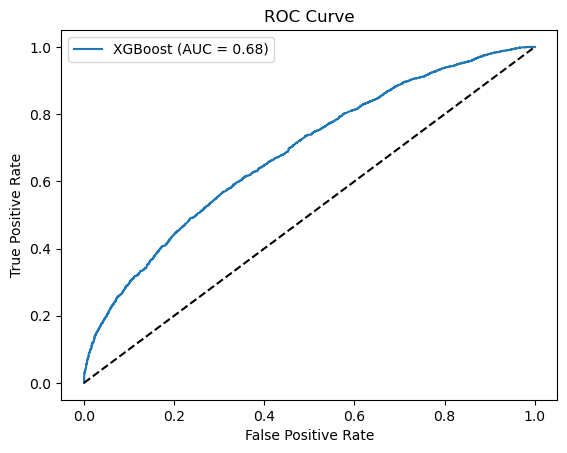

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label="XGBoost (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


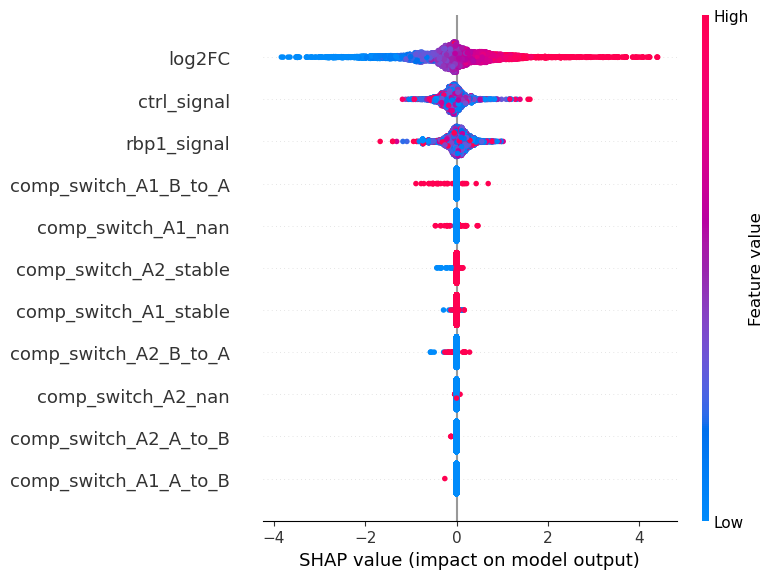

In [13]:
import shap

# Load explainer from model and training data
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), max_display=15)

### Logistic regression model

In [14]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train_lgr, X_test_lgr, y_train_lgr, y_test_lgr = train_test_split(X, y, test_size=0.25, random_state=16)

In [15]:
### code llm - for cleanup
# Handle data types and problematic values
# First, check for and handle infinite values
print("Checking for infinite values...")
if hasattr(X_train_lgr, 'replace'):  # if pandas DataFrame
    X_train_lgr = X_train_lgr.replace([np.inf, -np.inf], np.nan)
    X_test_lgr = X_test_lgr.replace([np.inf, -np.inf], np.nan)
else:  # if numpy array
    X_train_lgr[np.isinf(X_train_lgr)] = np.nan
    X_test_lgr[np.isinf(X_test_lgr)] = np.nan

# Handle missing values (including the inf values we just converted to NaN)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_lgr = imputer.fit_transform(X_train_lgr)
X_test_lgr = imputer.transform(X_test_lgr)

# Check for extremely large values that might cause overflow
print("Checking data ranges...")
print(f"X_train_lgr min: {np.min(X_train_lgr)}, max: {np.max(X_train_lgr)}")
print(f"X_test_lgr min: {np.min(X_test_lgr)}, max: {np.max(X_test_lgr)}")

# Convert to float32 after cleaning
X_train_lgr = X_train_lgr.astype(np.float32)
X_test_lgr = X_test_lgr.astype(np.float32)

# Convert target to integers if needed
y_train_lgr = y_train_lgr.astype(int)
y_test_lgr = y_test_lgr.astype(int)

Checking for infinite values...
Checking data ranges...
X_train_lgr min: -17.52109480589503, max: 16.791759928045582
X_test_lgr min: -16.517509535789017, max: 16.185442193508266


In [16]:
from sklearn.linear_model import LogisticRegression

#instantiate
lgr_ins = LogisticRegression(random_state=20)

lgr_ins.fit(X_train_lgr, y_train_lgr)

y_prediction = lgr_ins.predict(X_test_lgr)

In [17]:
# evaluate

from sklearn import metrics
cnf = metrics.confusion_matrix(y_test_lgr, y_prediction)
cnf

array([[4254,  462],
       [2264, 1090]])

Text(0.5, 427.9555555555555, 'Predicted label')

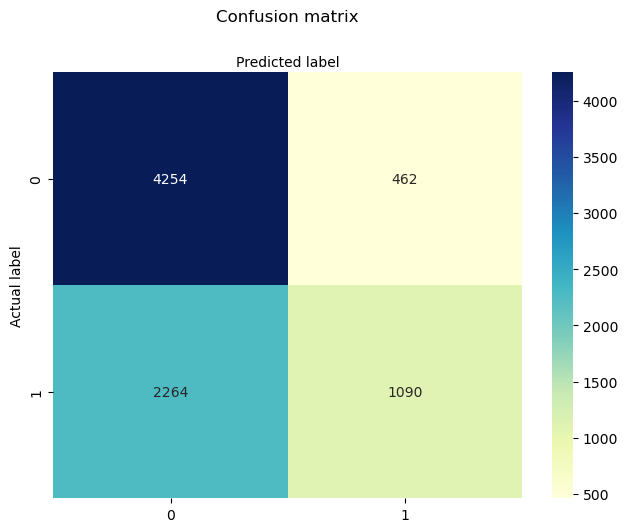

In [18]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [19]:
from sklearn.metrics import classification_report
target_names = ['control-loop', 'mutant-loop']
print(classification_report(y_test_lgr, y_prediction, target_names=target_names))

              precision    recall  f1-score   support

control-loop       0.65      0.90      0.76      4716
 mutant-loop       0.70      0.32      0.44      3354

    accuracy                           0.66      8070
   macro avg       0.68      0.61      0.60      8070
weighted avg       0.67      0.66      0.63      8070



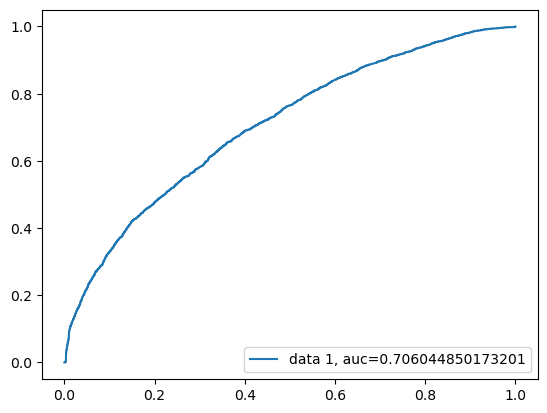

In [20]:
y_pred_proba_lgr = lgr_ins.predict_proba(X_test_lgr)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test_lgr,  y_pred_proba_lgr)
auc = metrics.roc_auc_score(y_test_lgr, y_pred_proba_lgr)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_test_lgr, y_pred_proba_lgr)

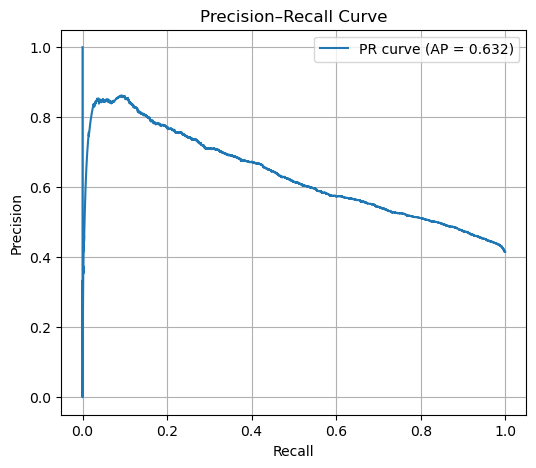

In [22]:
# Compute area under the precision-recall curve (average precision)
ap = average_precision_score(y_test_lgr, y_pred_proba_lgr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# fine tuning the model